In [4]:
import os
import chardet
import pandas as pd
from sklearn.model_selection import train_test_split

In [18]:
random_state = 7
no_of_active_features = 15

def get_encoding(file_path):
    with open(file_path, "rb") as f:
        data = f.read(10000)
    return chardet.detect(data).get("encoding")


def read_files(file_path: str):
    if file_path == None:
        print("Enter filepath")
        return

    false_feature_file = "rq2_vosoughi_False_features.csv"
    true_feature_file = "rq2_vosoughi_True_features.csv"
    true_file = os.path.join(file_path + os.path.sep + true_feature_file)
    false_file = os.path.join(file_path + os.path.sep + false_feature_file)

    vosoughi_false_df = pd.read_csv(
        false_file, index_col=0, sep=",", encoding=get_encoding(false_file)
    )
    vosoughi_true_df = pd.read_csv(
        true_file, index_col=0, sep=",", encoding=get_encoding(true_file)
    )
    vosoughi_df = pd.concat([vosoughi_false_df, vosoughi_true_df])
    return vosoughi_df


def filter_and_split_df(df: pd.DataFrame):

    test_size = 0.15

    filtered_df = df[(df.characteristic_distance != -99999) & (df.depth != 0)]
    filtered_df = filtered_df.drop(columns=["avg_cluster_coef"], axis=1)
    filtered_df = filtered_df.drop(["weakly_cc"], axis=1)
    total_features = no_of_active_features - 2

    X = filtered_df.iloc[:, 3:total_features]
    Y = filtered_df.iloc[:, total_features]
    X_train_val_full, X_test_full, y_train_val_full, y_test_full = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(X_train_val_full.shape, X_test_full.shape, y_train_val_full.shape, y_test_full.shape)
    
    return X_train_val_full, X_test_full, y_train_val_full, y_test_full

x_train_val_full, x_test_full, y_train_val_full, y_test_full = filter_and_split_df(read_files('.'))

(32305, 10) (5702, 10) (32305,) (5702,)


In [19]:
x_test_full.columns

Index(['depth', 'size', 'max_breadth', 'virality', 'strongly_cc',
       'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity',
       'characteristic_distance'],
      dtype='object')

In [16]:
import pickle 

with open("./x_train_val_full.pickle", "wb") as file:
    pickle.dump(x_train_val_full, file)

with open("./y_train_val_full.pickle", "wb") as file:
    pickle.dump(y_train_val_full, file)

with open("./x_test_full.pickle", "wb") as file:
    pickle.dump(x_test_full, file)

with open("./y_test_full.pickle", "wb") as file:
    pickle.dump(y_test_full, file)

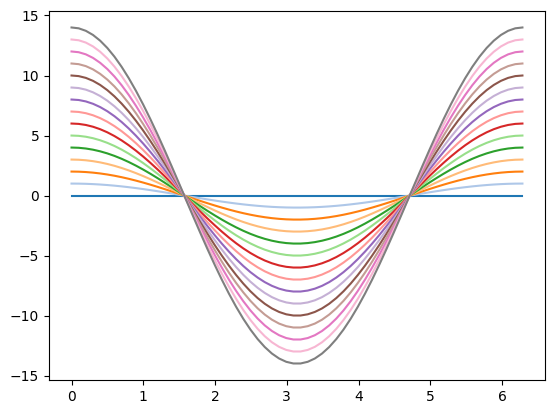

In [24]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as cm

x = np.linspace(0, 2*np.pi, 64)
y = np.cos(x) 

plt.figure()

n = 15
color = iter([cm.to_hex(plt.cm.tab20(i)) for i in range(n)])

for i in range(n):
    plt.plot(x, i*y, color=next(color))

In [37]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from copy import copy
from sklearn.preprocessing import StandardScaler

total_features = 13

x_train_file = "./rq2_x_train_df.csv"

train_file = os.path.join(x_train_file)

train_df = pd.read_csv(
    train_file, index_col=0, sep=","
)

X_train_val = train_df.iloc[:, 3:total_features]
y_train_val = train_df.iloc[:, total_features]

normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["size"], 0.25)
cd_third_quantile = np.quantile(normalized_df["size"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])
normalized_df["characteristic_distance"] = np.log(
    normalized_df["characteristic_distance"]
    + cd_first_quantile**2 / cd_third_quantile
)

In [1]:
import pickle
import pandas as pd

def read_pickled_input_files(file_path: str):
    
    X_train_val = None
    y_train_val = None
    X_test = None
    y_test = None

    # wandb.init(project=wandb_project)

    with open(file_path + "/x_train_val.pickle", "rb") as file:
        X_train_val = pickle.load(file)
        # joblib.dump(X_train_val, "x_train_val.joblib")
        # x_train_val_artifact = wandb.Artifact("x_train_val.joblib", type="dataset")
        # x_train_val_artifact.add_file("x_train_val.joblib")
        # wandb.log_artifact(x_train_val_artifact)

    with open(file_path + "/y_train_val.pickle", "rb") as file:
        y_train_val = pickle.load(file)
        # joblib.dump(y_train_val, "y_train_val.joblib")
        # y_train_val_artifact = wandb.Artifact("y_train_val.joblib", type="dataset")
        # y_train_val_artifact.add_file("y_train_val.joblib")
        # wandb.log_artifact(y_train_val_artifact)

    with open(file_path + "/x_test.pickle", "rb") as file:
        X_test = pickle.load(file)
        # joblib.dump(X_test, "x_test.joblib")
        # x_test_artifact = wandb.Artifact("x_test.joblib", type="dataset")
        # x_test_artifact.add_file("x_test.joblib")
        # wandb.log_artifact(x_test_artifact)

    with open(file_path + "/y_test.pickle", "rb") as file:
        y_test = pickle.load(file)
        # joblib.dump(y_test, "y_test.joblib")
        # y_test_artifact = wandb.Artifact("y_test.joblib", type="dataset")
        # y_test_artifact.add_file("y_test.joblib")
        # wandb.log_artifact(y_test_artifact)

    # wandb.finish()
    
    return X_train_val, X_test, y_train_val, y_test

X_train_val, X_test, y_train_val, y_test = read_pickled_input_files("./image")

print(f"shapes of input: {X_train_val.shape}, {X_test.shape}, {y_train_val.shape}, {y_test.shape}")

shapes of input: (32305, 8), (5702, 8), (32305,), (5702,)


In [6]:
X_train_val.columns

Index(['depth', 'max_breadth', 'virality', 'size_of_scc', 'density',
       'layer_ratio', 'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

In [ ]:
['depth', 'max_breadth', 
        'virality', 'size_of_scc', 'density',
       'layer_ratio', 'structural_heterogeneity', 'characteristic_distance',
       'veracity']
'size','strongly_cc'

In [3]:
import os
import wandb
from joblib import load
from sklearn.metrics import accuracy_score

os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"

# run = wandb.init(project="test-1", job_type="demo_run_2")

run = wandb.init(project="RQ2RUN1")

artifact = run.use_artifact("RQ2RUN1/Logistic-Model:latest")

model_dir = artifact.download()
# print("model: ", os.path.join(model_dir, "clf.joblib"))
model = load(os.path.join(model_dir, "logit.joblib"))


y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

wandb:   1 of 1 files downloaded.  


0.8386531041739741


C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
